<a href="https://colab.research.google.com/github/aqmalio/Data-Science-2026/blob/main/Pertemuan6_Aqmal_250401020149.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
* Nama: Aqmal
* Nim: 250401020149
* Kelas: IF405
---



#### Load & EDA Singkat
Muat dataset, periksa missing values, tipe data, dan distribusi target.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

# Pilih kolom yang akan digunakan
cols = ['pclass','sex','age','sibsp','parch','fare','embarked','survived']
df = df[cols].copy()

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDistribusi target:')
print(df['survived'].value_counts(normalize=True).round(3))

Shape: (891, 8)

Missing values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Distribusi target:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


#### Handling Missing Values
Isi nilai yang hilang sebelum encoding.

In [2]:
# Age: isi dengan median (robust terhadap outlier)
df['age'] = df['age'].fillna(df['age'].median())

# Embarked: isi dengan modus (nilai paling sering)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('Missing setelah handling:')
print(df.isnull().sum())

Missing setelah handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


#### Encoding Kategorikal
Terapkan One-Hot Encoding pada kolom 'sex' dan 'embarked'.

In [3]:
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True, dtype=int)

print('Kolom setelah encoding:')
print(df.columns.tolist())

Kolom setelah encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']


#### Train-Test Split
Bagi data dengan stratifikasi.

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test : {X_test.shape[0]} baris')

Train: 712 baris
Test : 179 baris


#### Feature Scaling
Terapkan StandardScaler pada kolom numerik.

In [5]:
from sklearn.preprocessing import StandardScaler

num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('X_train setelah scaling:')
display(X_train.head(3).round(3))

print('\nData siap dilatih model ML')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}, y_test : {y_test.shape}')

X_train setelah scaling:


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
692,0.830,-0.112,-0.465,-0.466,0.514,1,0,1
481,-0.371,-0.112,-0.465,-0.466,-0.663,1,0,1
527,-1.571,-0.112,-0.465,-0.466,3.955,1,0,1



Data siap dilatih model ML
X_train: (712, 8), y_train: (712,)
X_test : (179, 8), y_test : (179,)


#### Model Training & Evaluation
Latih model Logistic Regression dan evaluasi performanya menggunakan test set.

Accuracy Score: 0.8045

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



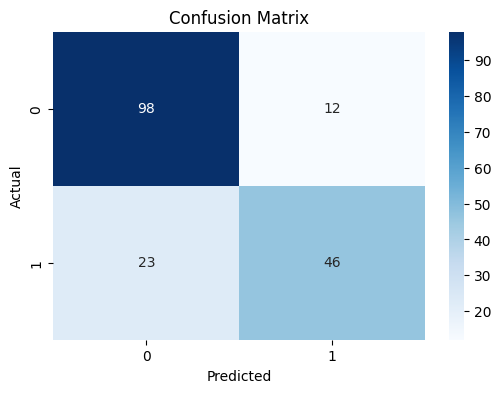

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Inisialisasi dan training model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediksi pada data test
y_pred = model.predict(X_test)

# Evaluasi
print('Accuracy Score:', round(accuracy_score(y_test, y_pred), 4))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Kesimpulan

**Apa yang dipelajari:**
Pada Sesi ini, hal yang dipelajari adalah mendemonstrasikan alur kerja data science dasar (end-to-end ML pipeline) mulai dari pemuatan data, pembersihan data (handling missing values), encoding variabel kategorikal, pembagian dataset, hingga penskalaan fitur dan evaluasi model.

**Temuan Utama:**
- Model Logistic Regression mampu memprediksi kelangsungan hidup penumpang Titanic dengan tingkat akurasi yang cukup baik setelah fitur numerik distandarisasi.
- Fitur seperti `sex`, `pclass`, dan `fare` merupakan prediktor penting dalam model ini.

**Keterbatasan & Pertanyaan:**
- Imputasi missing values pada `age` menggunakan median mungkin terlalu sederhana; metode yang lebih canggih.